# 04 · The full pipeline, stage by stage

This is the complete picture: a document image goes in, extracted text and a
located pattern come out, with every intermediate stage opened up and inspected.

```
document image
 1. preprocess      median filter, Otsu threshold, speckle removal
 2. segment         projection profiles -> lines -> character boxes
 3. crop            pad to square, resize to 8x8, normalise
 4. encode          RY angles -> 4 qubits per patch          QUANTUM
 5. filter          entangling circuit -> 160 features       QUANTUM
 6. classify        logistic regression -> characters
 7. assemble        rebuild lines, insert spaces
 8. locate          find the identifier field
 9. search          Grover comparator oracle                 QUANTUM
```

Along the way this notebook covers the two bugs that cost the most and taught
the most: a **train/serve skew** that was inflating error 6.6×, and an
**identifier extraction** rule that was confidently searching the wrong field.
Both were invisible until specifically looked for.

Runtime: roughly five minutes on CPU.

## Setup

In [27]:
# Environment setup — works on Colab and on a local checkout.
#
# Safe to run in any order and any number of times. If another notebook in this
# session already cloned the repo, this reuses it rather than trying to clone
# again (which fails with "destination path already exists", exit 128).

import os, sys, subprocess, pathlib, importlib

REPO_URL = "https://github.com/Pushkar0997/qi26_25.git"
REPO_DIR = "qi26_25"
IN_COLAB = "google.colab" in sys.modules

# A file that exists only in this repo, used to recognise a valid checkout.
MARKER = pathlib.Path("integration") / "features.py"


def _is_root(p):
    return (p / MARKER).exists()


def _find_root():
    """Locate the repo, checking three places in order.

    Searching UPWARD alone is not enough. On Colab every notebook gets a fresh
    kernel starting at /content, so a second notebook would look at /content and
    its parents, miss the /content/qi26_25 that the first notebook cloned, and
    try to clone again into a directory that already exists.
    """
    here = pathlib.Path.cwd().resolve()

    # 1. Here or above — a local checkout, or a notebook opened from notebooks/.
    for cand in [here, *here.parents]:
        if _is_root(cand):
            return cand

    # 2. One level down — a clone made earlier in this session.
    for cand in [here / REPO_DIR, pathlib.Path("/content") / REPO_DIR]:
        if _is_root(cand):
            return cand.resolve()

    return None


root = _find_root()
if root is None:
    target = pathlib.Path.cwd() / REPO_DIR
    if target.exists():
        raise SystemExit(
            f"{target} exists but does not contain {MARKER}.\n"
            f"It may be a partial clone. Remove it and re-run this cell:\n"
            f"    !rm -rf {target}")
    print("cloning repository ...")
    subprocess.run(["git", "clone", "--quiet", REPO_URL, str(target)], check=True)
    root = _find_root()
    if root is None:
        raise SystemExit("clone succeeded but the repo layout was not found")
else:
    print("using existing checkout")

os.chdir(root)

# Put the package directories on the path. These modules import each other by
# bare name, so the directories themselves go on sys.path, not the repo root.
for sub in ["integration", "track_b_search/oracle", "data", "benchmarking",
            "track_a_vision/quanvolutional", "track_a_vision/encoding"]:
    d = str(root / sub)
    if d not in sys.path:
        sys.path.insert(0, d)

# Install only what is missing — Colab already ships numpy/scipy/sklearn/PIL.
need = []
for mod, pkg in [("qiskit", "qiskit>=2.0,<3.0"), ("qiskit_aer", "qiskit-aer"),
                 ("sklearn", "scikit-learn"), ("scipy", "scipy"),
                 ("PIL", "pillow"), ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        need.append(pkg)
if need:
    print("installing:", " ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)

import qiskit, numpy as np
print("repo root :", root)
print("colab     :", IN_COLAB)
print("qiskit    :", qiskit.__version__, "| numpy:", np.__version__)

using existing checkout
repo root : /content/qi26_25
colab     : True
qiskit    : 2.5.2 | numpy: 2.0.2


Generate the dataset and train the OCR head if they are not already present.

In [28]:
# Generate data and train the OCR head if needed.
#
# The dataset check looks for a real data file rather than manifest.json: the
# manifest is committed to the repo but the images are gitignored, so on a fresh
# clone the manifest exists while the data does not.
import subprocess, sys
from pathlib import Path

TIERS = ["clean_digital", "clean_scan", "noisy_scan",
         "clear_handwriting", "degraded_handwriting"]
if not all((Path("data/processed") / t / "chars.npz").exists() for t in TIERS):
    print("generating dataset ...")
    subprocess.run([sys.executable, "data/generate_dataset.py",
                    "--docs-per-tier", "12", "--seed", "26"], check=True)
if not Path("integration/ocr_backend.npz").exists():
    print("training OCR backend ...")
    subprocess.run([sys.executable, "integration/pipeline.py", "--train"], check=True)
print("ready")

ready


image      : (420, 620) | dtype uint8
document ID: QI96-3898
true text  :
    QWORLD RESEARCH INSTITUTE
    DOCUMENT ID: QI96-3898
    DEPT: OPERATIONS
    SUBJECT: FEATURE MAP ANALYSIS
    REF: 5103   PAGE: 08


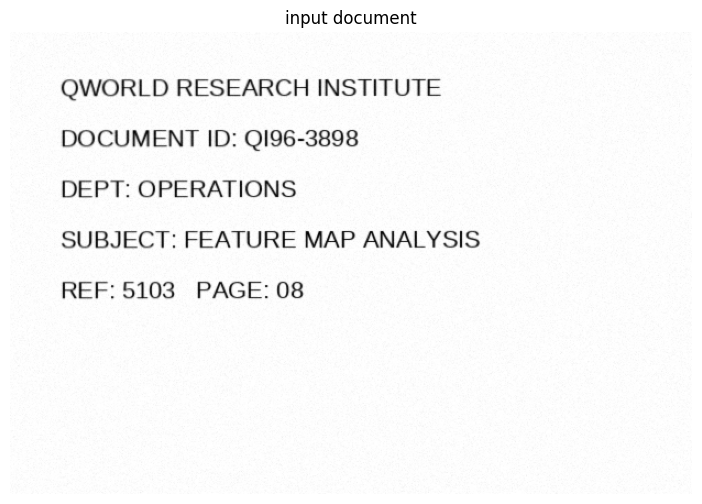

In [29]:
import numpy as np, json
import matplotlib.pyplot as plt
from PIL import Image
import pipeline as P

DOC = "data/processed/clean_scan/doc_000.png"
arr = np.array(Image.open(DOC).convert("L"), dtype=np.uint8)
meta = json.loads(Path(DOC.replace(".png", ".json")).read_text())

print("image      :", arr.shape, "| dtype", arr.dtype)
print("document ID:", meta["doc_id"])
print("true text  :")
for line in meta["text"].split("\n"):
    print("   ", line)

plt.figure(figsize=(9, 6)); plt.imshow(arr, cmap="gray"); plt.axis("off")
plt.title("input document"); plt.show()

## Stage 1 · Preprocessing

Three operations, each fixing a specific failure.

**Median filter (3×3).** Removes isolated speckle while preserving edges, unlike
a Gaussian blur which would smear thin strokes.

**Otsu threshold.** Picks the intensity cut that maximises between-class
variance — chosen over a fixed threshold because the tiers differ enormously in
overall brightness, and any constant would fail on at least one of them.

**Speckle removal.** Drops connected components too small to be a stroke. This
one is not cosmetic: without it the noisy tiers put sub-threshold pixels in
*every* row of the page, so line detection found a single 420-row "line" and
segmentation collapsed entirely.

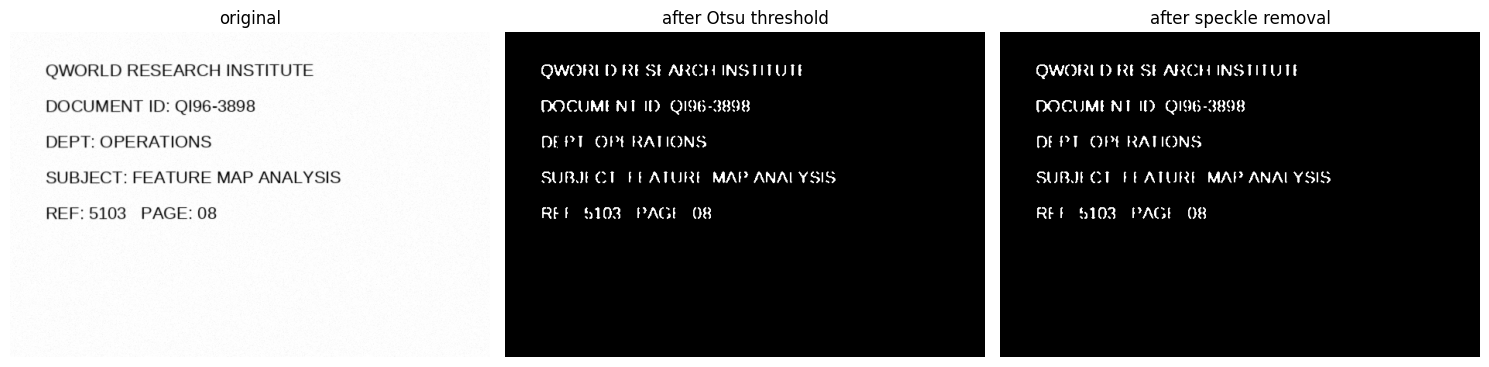

ink pixels before speckle removal: 6145
ink pixels after                 : 6141
removed                          : 4


In [30]:
from scipy import ndimage

smoothed = ndimage.median_filter(arr, size=3)
thresh = P.binarize(smoothed)
raw_ink = smoothed <= np.argmax([0])  # placeholder, replaced below
raw_ink = P.binarize(smoothed)
clean_ink = P.clean_ink(raw_ink)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, im, t in zip(ax, [arr, raw_ink, clean_ink],
                    ["original", "after Otsu threshold", "after speckle removal"]):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

print("ink pixels before speckle removal:", int(raw_ink.sum()))
print("ink pixels after                 :", int(clean_ink.sum()))
print("removed                          :", int(raw_ink.sum() - clean_ink.sum()))

### Why 4-connectivity, not 8

The connected-component labelling uses `scipy.ndimage.label`, whose **default is
4-connectivity** (a cross-shaped structuring element). Diagonally touching pixels
are treated as separate components.

This looks like a trivia detail. It is not: when the browser port of this
pipeline used 8-connectivity instead, a diagonally-adjacent speckle merged into a
glyph, changed which blobs survived the size filter, moved one bounding box by a
single pixel, and produced a different decoded character. It took a
stage-by-stage comparison against Python to find.

In [31]:
cross = ndimage.generate_binary_structure(2, 1)   # scipy default, 4-connectivity
full  = ndimage.generate_binary_structure(2, 2)   # 8-connectivity
print("4-connectivity structure:\n", cross.astype(int))
print("\n8-connectivity structure:\n", full.astype(int))

n4 = ndimage.label(raw_ink, structure=cross)[1]
n8 = ndimage.label(raw_ink, structure=full)[1]
print(f"\ncomponents found: 4-conn {n4}, 8-conn {n8}  (difference: {n4-n8})")

4-connectivity structure:
 [[0 1 0]
 [1 1 1]
 [0 1 0]]

8-connectivity structure:
 [[1 1 1]
 [1 1 1]
 [1 1 1]]

components found: 4-conn 144, 8-conn 144  (difference: 0)


## Stage 2 · Segmentation by projection profiles

Sum ink along rows to find text lines; within each line, sum along columns to
find characters. Runs of blank columns are the separators.

The row threshold is **adaptive** — a real text line marks a meaningful fraction
of the page width. A fixed "more than 1 pixel" test is what let residual noise
merge the whole page into one line on degraded scans.

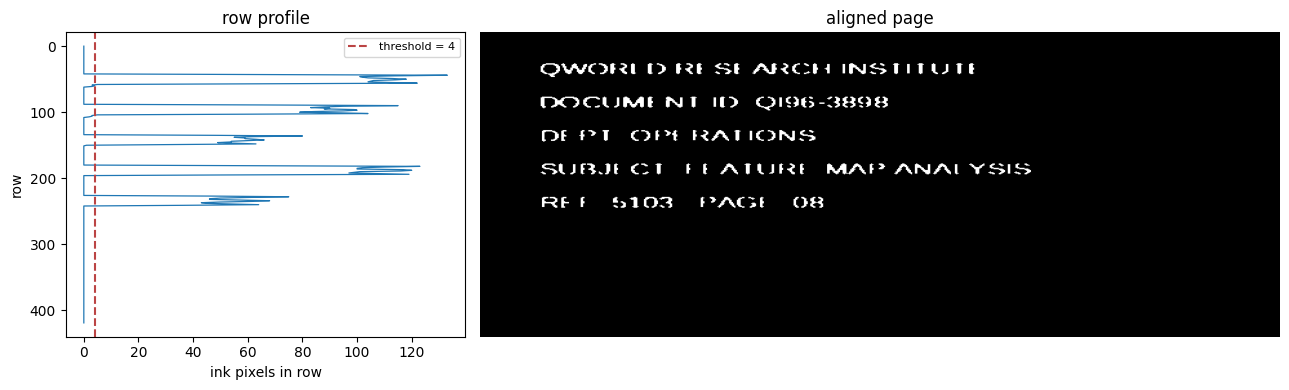

detected 5 text lines: [(43, 59), (89, 105), (135, 150), (181, 196), (227, 242)]


In [32]:
row_ink = clean_ink.sum(axis=1)
row_thresh = max(2, int(0.008 * clean_ink.shape[1]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4),
                       gridspec_kw={"width_ratios": [1, 2]})
ax[0].plot(row_ink, np.arange(len(row_ink)), lw=.9)
ax[0].axvline(row_thresh, c="#b44", ls="--", label=f"threshold = {row_thresh}")
ax[0].invert_yaxis(); ax[0].set_xlabel("ink pixels in row")
ax[0].set_ylabel("row"); ax[0].legend(fontsize=8); ax[0].set_title("row profile")
ax[1].imshow(clean_ink, cmap="gray", aspect="auto"); ax[1].axis("off")
ax[1].set_title("aligned page")
plt.tight_layout(); plt.show()

active = row_ink > row_thresh
lines, start = [], None
for y, a in enumerate(active):
    if a and start is None: start = y
    elif not a and start is not None:
        if y - start >= 4: lines.append((start, y))
        start = None
print(f"detected {len(lines)} text lines:", lines)

Within one line, the column profile separates characters. The gaps between words are visibly wider than the gaps between letters — that difference is what stage 7 uses to reinsert spaces.

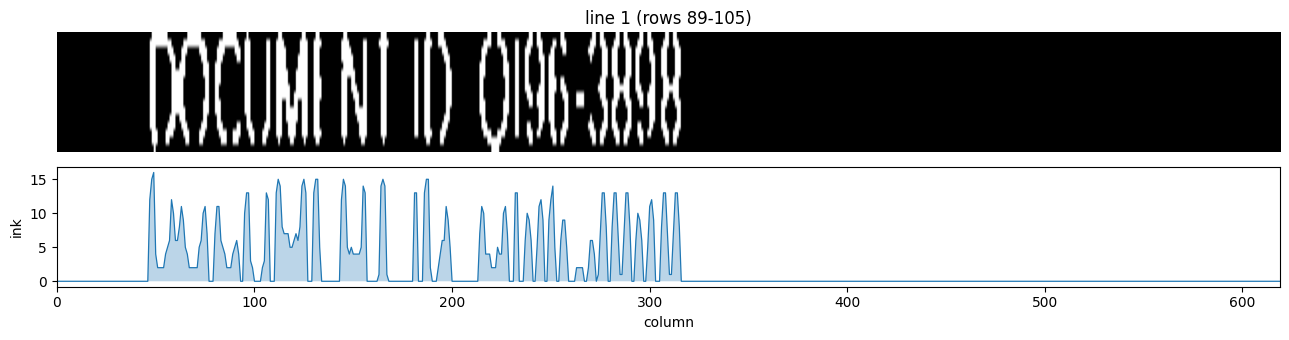

In [33]:
y0, y1 = lines[1]
band = clean_ink[y0:y1]
col_ink = band.sum(axis=0)

plt.figure(figsize=(13, 3.5))
plt.subplot(2, 1, 1); plt.imshow(band, cmap="gray", aspect="auto"); plt.axis("off")
plt.title(f"line 1 (rows {y0}-{y1})")
plt.subplot(2, 1, 2); plt.plot(col_ink, lw=.9); plt.fill_between(range(len(col_ink)), col_ink, alpha=.3)
plt.xlabel("column"); plt.ylabel("ink"); plt.margins(x=0)
plt.tight_layout(); plt.show()

segmented 145 character boxes (ground truth: 99 characters)
segmentation ratio: 1.46


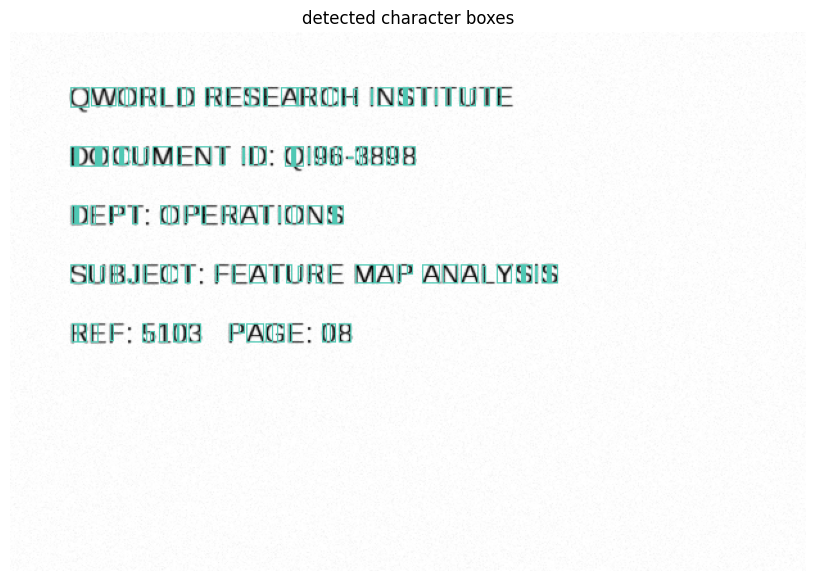

In [34]:
boxes = P.segment_characters(arr)
print(f"segmented {len(boxes)} character boxes "
      f"(ground truth: {len(meta['char_labels'])} characters)")
print(f"segmentation ratio: {len(boxes)/len(meta['char_labels']):.2f}")

vis = np.stack([arr]*3, axis=-1).copy()
for (_, x0, yy0, x1, yy1) in boxes:
    vis[yy0:yy1, x0:x0+1] = [80, 200, 180]; vis[yy0:yy1, x1-1:x1] = [80, 200, 180]
    vis[yy0:yy0+1, x0:x1] = [80, 200, 180]; vis[yy1-1:yy1, x0:x1] = [80, 200, 180]
plt.figure(figsize=(11, 7)); plt.imshow(vis); plt.axis("off")
plt.title("detected character boxes"); plt.show()

### Splitting merged glyphs — and why not by equal widths

On low-DPI scans, downsampling plus blur closes the gap between adjacent glyphs,
so the column profile sees no separator and returns one box covering several
characters.

The obvious fix is to cut a too-wide box into equal slices. That was tried and it
was **wrong**: on the degraded tiers it over-segmented badly, cutting single
characters apart and pushing error above 100% through pure insertions. The
working version cuts only at genuine valleys in the ink profile, and leaves a box
alone if it has none — so a legitimately wide `M` survives intact.

reference width (60th pct): 5 px
boxes wide enough to test for splitting: 22


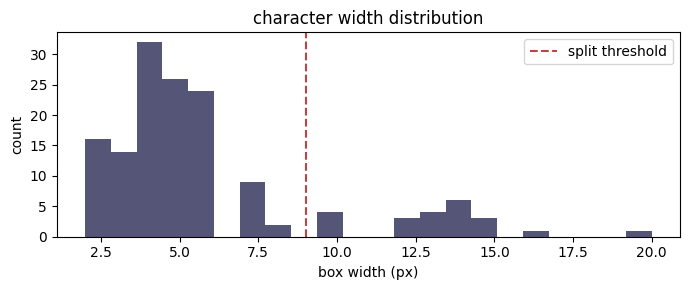

In [35]:
widths = np.array([b[3]-b[1] for b in boxes])
ref = np.percentile(widths, 60)
wide = [b for b in boxes if (b[3]-b[1]) > 1.8*ref]
print(f"reference width (60th pct): {ref:.0f} px")
print(f"boxes wide enough to test for splitting: {len(wide)}")
plt.figure(figsize=(7, 3)); plt.hist(widths, bins=22, color="#557")
plt.axvline(1.8*ref, c="#b44", ls="--", label="split threshold")
plt.xlabel("box width (px)"); plt.ylabel("count"); plt.legend()
plt.title("character width distribution"); plt.tight_layout(); plt.show()

## Stage 3 · Cropping — where aspect ratio nearly ruined everything

Each box is padded to a square, *then* resized to 8×8.

The padding step is not decoration. Resizing a box straight to 8×8 destroys
aspect ratio, and for OCR that is not cosmetic: a colon is two small dots in a
narrow tall box, and stretched to a square it becomes two thick horizontal bands
closely resembling an `E`. Before this was fixed, `C`→`:` and `E`→`:` confusions
dominated the error, and CER was 32%. Padding first preserves the width-to-height
relationship, and the padding margin itself encodes how narrow the glyph was.

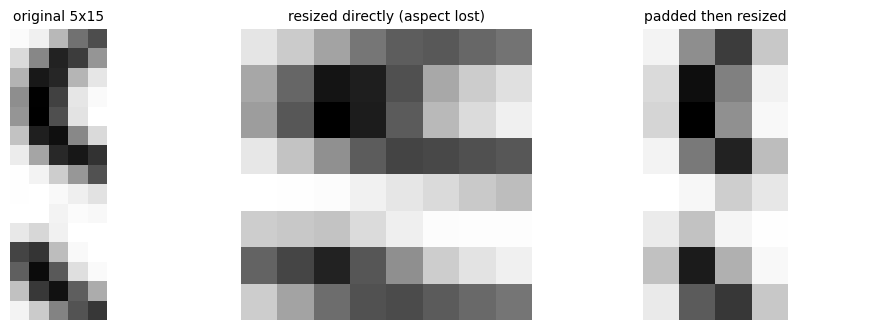

In [36]:
from features import square_pad_resize, normalize_crops

demo = boxes[12]
sub = arr[demo[2]:demo[4], demo[1]:demo[3]]
naive = np.array(Image.fromarray(sub).resize((8, 8), Image.BILINEAR))
padded = square_pad_resize(sub, 8)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
for a, im, t in zip(ax, [sub, naive, padded],
                    [f"original {sub.shape[1]}x{sub.shape[0]}",
                     "resized directly (aspect lost)", "padded then resized"]):
    a.imshow(im, cmap="gray", interpolation="nearest"); a.set_title(t, fontsize=10); a.axis("off")
plt.tight_layout(); plt.show()

crops: (145, 8, 8) -> normalised range per crop is stretched to 0-255


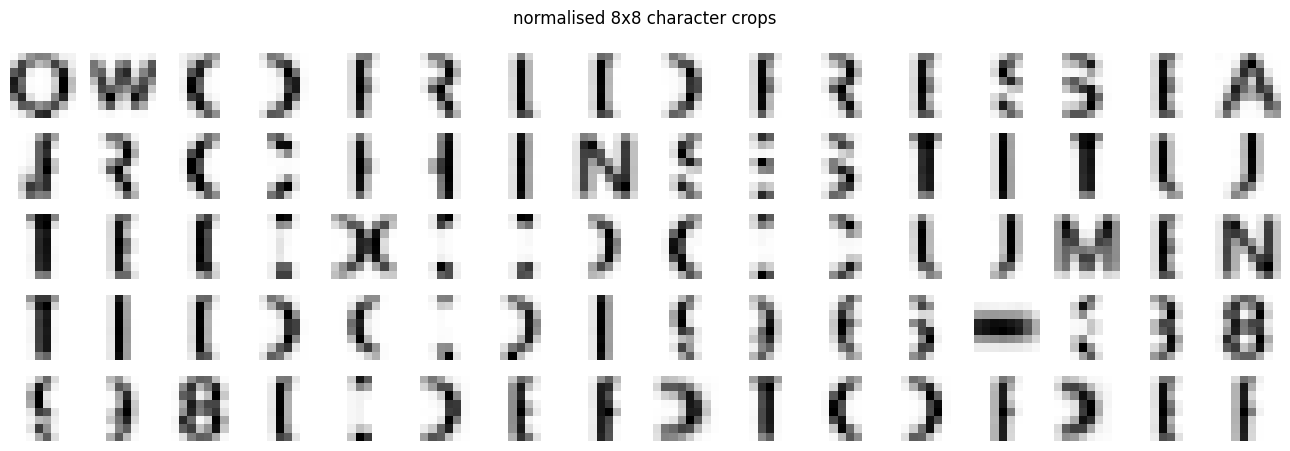

In [37]:
crops = P.crops_from_boxes(arr, boxes)
norm = normalize_crops(crops)
print("crops:", crops.shape, "-> normalised range per crop is stretched to 0-255")

fig, axes = plt.subplots(5, 16, figsize=(13, 4.6))
for i, a in enumerate(axes.flat):
    if i < len(norm): a.imshow(norm[i], cmap="gray", interpolation="nearest")
    a.axis("off")
plt.suptitle("normalised 8x8 character crops", y=.98); plt.tight_layout(); plt.show()

Normalisation matters most on the degraded tiers. Those reduce contrast globally,
and the encoder maps intensity to a rotation angle — so without a per-crop
stretch, a faded character and a blank patch produce nearly the same angles.

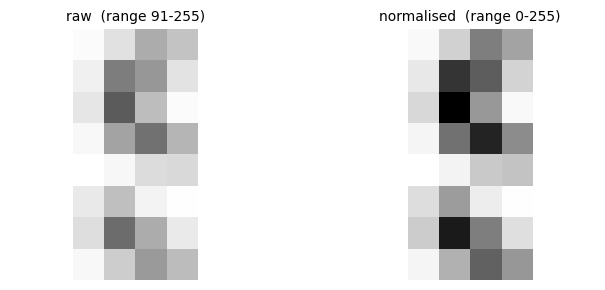

In [38]:
i = 12
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(crops[i], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
ax[0].set_title(f"raw  (range {crops[i].min()}-{crops[i].max()})", fontsize=10)
ax[1].imshow(norm[i], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
ax[1].set_title(f"normalised  (range {norm[i].min():.0f}-{norm[i].max():.0f})", fontsize=10)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Stages 4–5 · The quantum feature extractor

Each 8×8 crop is cut into sixteen 2×2 patches. Every patch is angle-encoded onto
4 qubits, run through the fixed entangling filter, and read out as 4 single-qubit
marginals plus 6 pairwise ⟨Z_i Z_j⟩ correlations — 10 numbers per patch, 160 per
character.

Notebook `02` derives why this is a matrix multiply rather than a simulation, and
verifies it against Qiskit's simulator.

In [39]:
from features import quanv_features, quanv_patch_probs, random_entangling_circuit

filt = random_entangling_circuit(4, seed=42, depth=2)
print(filt.draw("text"))

     ┌────────────┐                      ┌───┐┌─────────────┐               »
q_0: ┤ Ry(4.8629) ├──■───────────────────┤ X ├┤ Ry(0.59173) ├──■────────────»
     ├────────────┤┌─┴─┐     ┌──────────┐└─┬─┘└─────────────┘┌─┴─┐          »
q_1: ┤ Ry(2.7576) ├┤ X ├──■──┤ Ry(6.13) ├──┼─────────────────┤ X ├──■───────»
     ├────────────┤└───┘┌─┴─┐└──────────┘  │   ┌────────────┐└───┘┌─┴─┐     »
q_2: ┤ Ry(5.3947) ├─────┤ X ├─────■────────┼───┤ Ry(4.7824) ├─────┤ X ├──■──»
     ├────────────┤     └───┘   ┌─┴─┐      │   ├───────────┬┘     └───┘┌─┴─┐»
q_3: ┤ Ry(4.3817) ├─────────────┤ X ├──────■───┤ Ry(4.939) ├───────────┤ X ├»
     └────────────┘             └───┘          └───────────┘           └───┘»
«     ┌───┐
«q_0: ┤ X ├
«     └─┬─┘
«q_1: ──┼──
«       │  
«q_2: ──┼──
«       │  
«q_3: ──■──
«          


In [40]:
crop = norm[12]
patch = crop[0:2, 0:2].flatten()
probs = quanv_patch_probs(patch[None, :], correlations=True)[0]
print("one 2x2 patch:", patch.astype(int))
print("\n4 marginals  P(qubit=1):", np.round(probs[:4], 3))
print("6 correlations <Z_i Z_j> :", np.round(probs[4:], 3))

one 2x2 patch: [255 255 255 255]

4 marginals  P(qubit=1): [0.42  0.52  0.535 0.392]
6 correlations <Z_i Z_j> : [-0.451 -0.542  0.049  0.738 -0.274 -0.335]


features: (145, 160) = (characters, 16 patches x 10 readouts)


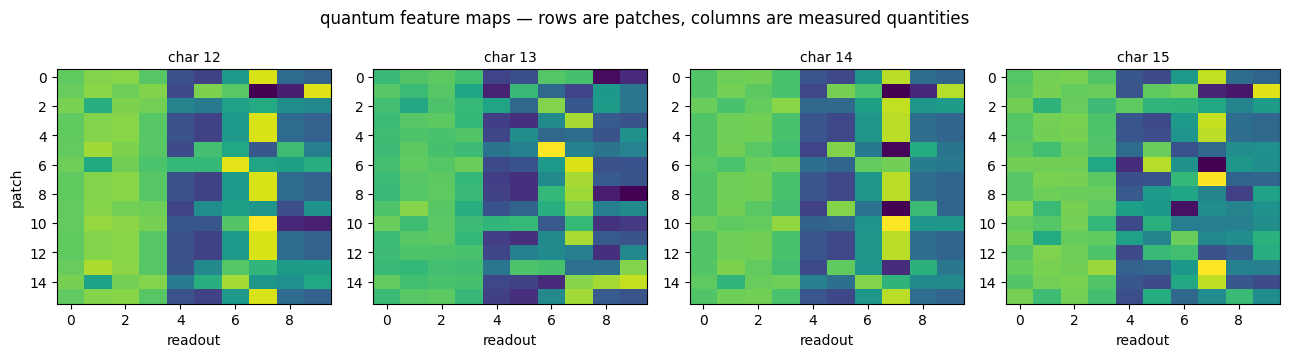

In [41]:
feats = quanv_features(norm, correlations=True)
print("features:", feats.shape, "= (characters, 16 patches x 10 readouts)")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for a, i in zip(axes, [12, 13, 14, 15]):
    a.imshow(feats[i].reshape(16, 10), cmap="viridis", aspect="auto")
    a.set_title(f"char {i}", fontsize=10)
    a.set_xlabel("readout"); a.set_ylabel("patch" if i == 12 else "")
plt.suptitle("quantum feature maps — rows are patches, columns are measured quantities")
plt.tight_layout(); plt.show()

## Stage 6 · Classification

A multinomial logistic regression maps 160 features to characters. This is the
"lightweight classical OCR back-end" the brief asks for: feature extraction is
quantum, the decision layer is not.

In [42]:
coef, intercept, classes = P.load_backend()
print("classes:", "".join(sorted(classes)))
print("weights:", coef.shape)

chars = P.predict_chars(crops, coef, intercept, classes)
logits = feats @ coef.T + intercept
e = np.exp(logits - logits.max(axis=1, keepdims=True))
conf = (e / e.sum(axis=1, keepdims=True)).max(axis=1)

print(f"\nmean confidence: {conf.mean():.1%}")
print(f"below 50%      : {(conf < .5).sum()} of {len(conf)} characters")

classes: -0123456789:ABCDEFGHIJKLMNOPQRSTUVWY
weights: (36, 160)

mean confidence: 67.4%
below 50%      : 42 of 145 characters


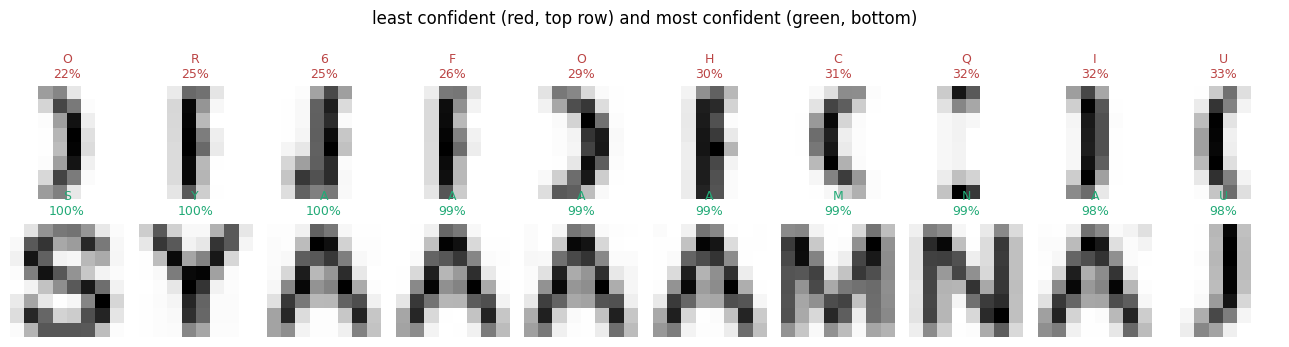

In [43]:
order = np.argsort(conf)
fig, axes = plt.subplots(2, 10, figsize=(13, 3.4))
for k, a in enumerate(axes.flat):
    idx = order[k] if k < 10 else order[-(k - 9)]
    a.imshow(norm[idx], cmap="gray", interpolation="nearest")
    a.set_title(f"{chars[idx]}\n{conf[idx]:.0%}", fontsize=9,
                color="#b44" if k < 10 else "#2a7")
    a.axis("off")
plt.suptitle("least confident (red, top row) and most confident (green, bottom)", y=1.02)
plt.tight_layout(); plt.show()

## Stage 7 · Reassembling text

Characters are grouped back into lines and spaces reinserted where the horizontal
gap is unusually large.

The threshold comes from the **gap distribution itself**, not from glyph width.
Glyph widths vary far too much between `I` and `M` to be a useful reference,
whereas word gaps are consistent outliers among mostly-uniform letter gaps.

In [44]:
text = P.assemble_text(boxes, chars)
print("EXTRACTED:"); print(text)
print("\nGROUND TRUTH:"); print(meta["text"])
print(f"\nCER: {P.cer(text, meta['text']):.1%}")

EXTRACTED:
QWCOFRL DO RRE SSE A6RCCHH INSSSTITUUTE
UODOOOCCCUUME NT IDO CQQI99E6-338998
DQDR HPT CSRPE RRATICDNSSS
SUUR3CIECCT REATUURRE MARPANALYSSSISSS
RRER 551UO3 RPACGE UO8

GROUND TRUTH:
QWORLD RESEARCH INSTITUTE
DOCUMENT ID: QI96-3898
DEPT: OPERATIONS
SUBJECT: FEATURE MAP ANALYSIS
REF: 5103   PAGE: 08

CER: 64.3%


## Stage 8 · Finding the identifier — two bugs deep

The field handed to Grover is chosen by **layout**, not keyword: the label itself
is OCR output and comes back as things like `OOCUMENT IO:`, so matching on it is
unreliable.

Both halves of the current rule were forced by observed failures.

**Scoring per line rather than per token.** When OCR drops the colon in
`DOCUMENT ID: QI96-3898`, there is no label/value split, so the `D`, `C` and `E`
of the word "DOCUMENT" get harvested as hex digits — the field came out as
`DCED963898` and every reported match position was shifted by six.

**Scoring by digit density alone.** That ranked a short all-numeric field
(`REF 7128`, density 1.0) *above* a longer alphanumeric identifier
(`QI87-12D0` → `8712D0`, density 0.83). The pipeline confidently searched the
reference number instead of the document ID.

Neither is visible unless the extracted field is checked against ground truth.

In [45]:
def score_variants(line_text):
    print(f"{'token':14s} {'hex part':12s} {'len':>4s} {'digits':>7s} "
          f"{'density-only':>13s} {'length-weighted':>16s}")
    for line in line_text.upper().split("\n"):
        for tok in line.replace(":", " ").split():
            h = "".join(c for c in tok if c in "0123456789ABCDEF")
            if len(h) < 3: continue
            d = sum(c.isdigit() for c in h)
            old = d / len(h) + 0.05 * len(h)
            new = 0 if d == 0 else len(h) * (0.5 + 0.5 * d / len(h))
            print(f"{tok:14s} {h:12s} {len(h):>4d} {d:>7d} {old:>13.3f} {new:>16.3f}")

score_variants(text)
print("\nselected:", repr(P._locate_id_field(text)))
true_hex = "".join(c for c in meta["doc_id"].upper() if c in "0123456789ABCDEF")
print("true ID :", meta["doc_id"], "-> hex part", repr(true_hex))
print("match   :", P._locate_id_field(text) == true_hex)

token          hex part      len  digits  density-only  length-weighted
A6RCCHH        A6CC            4       1         0.450            2.500
UODOOOCCCUUME  DCCCE           5       0         0.250            0.000
CQQI99E6-338998 C99E6338998    11       9         1.368           10.000
RRATICDNSSS    ACD             3       0         0.150            0.000
SUUR3CIECCT    3CECC           5       1         0.450            3.000
REATUURRE      EAE             3       0         0.150            0.000
MARPANALYSSSISSS AAA             3       0         0.150            0.000
551UO3         5513            4       4         1.200            4.000
RPACGE         ACE             3       0         0.150            0.000

selected: 'C99E6338998'
true ID : QI96-3898 -> hex part '963898'
match   : False


## Stage 9 · Grover search over the recovered field

The identifier goes to the comparator oracle from notebook `03`. Note this is now
searching a field that was *read off an image by a quantum feature extractor* —
both quantum stages in one path.

In [46]:
field = P._locate_id_field(text)
res = P.search_extracted_id(text, field[:2] if len(field) >= 2 else "26")
for k, v in res.items():
    print(f"  {k:20s} {v}")

  searchable_field     C99E6338998
  pattern              C9
  true_positions       [0]
  grover_position      0
  correct              True
  confidence           0.96
  iterations           3
  phase_check_ok       True
  uncompute_leakage    0.0


## The whole thing, in one call

In [47]:
result = P.run_document(DOC, pattern="38", verbose=True)

FILE : doc_000.png | TIER: clean_scan
SEGMENTED: 145 boxes (truth 99 chars)
--------------------------------------------------------------
EXTRACTED:
QWCOFRL DO RRE SSE A6RCCHH INSSSTITUUTE
UODOOOCCCUUME NT IDO CQQI99E6-338998
DQDR HPT CSRPE RRATICDNSSS
SUUR3CIECCT REATUURRE MARPANALYSSSISSS
RRER 551UO3 RPACGE UO8
--------------------------------------------------------------
GROUND TRUTH:
QWORLD RESEARCH INSTITUTE
DOCUMENT ID: QI96-3898
DEPT: OPERATIONS
SUBJECT: FEATURE MAP ANALYSIS
REF: 5103   PAGE: 08
--------------------------------------------------------------
CER: 64.3%
--------------------------------------------------------------
GROVER SEARCH:
  searchable_field     C99E6338998
  pattern              38
  true_positions       [6]
  grover_position      6
  correct              True
  confidence           0.957
  iterations           3
  phase_check_ok       True
  uncompute_leakage    0.0


## The bug that cost the most: train/serve skew

This is the single largest improvement in the project, and it came from a data
plumbing defect rather than any modelling change.

**The symptom that exposed it.** Switching the feature stage from the 64-dim
marginal readout to the 160-dim +ZZ readout *raised* isolated-character accuracy
(notebook `02` measures this) but made end-to-end CER **worse**. A strictly
better feature set producing strictly worse output is impossible if both are
measured on the same inputs — so they were not.

**The cause.** Training crops were cut from the exact glyph bounds recorded at
dataset generation. Inference crops come from projection segmentation. Those are
measurably different distributions.

source                           n   median w   median h
ground-truth glyph bounds       99         16         19
segmentation output            145          5         15


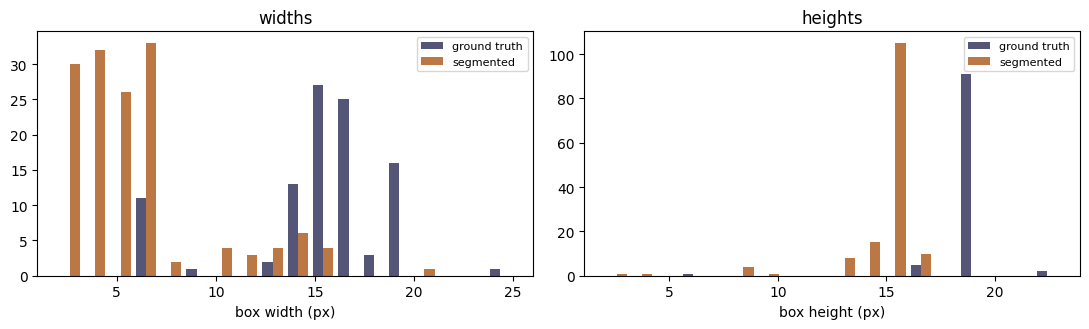

In [48]:
gt = np.array(meta["char_boxes"])
sb = np.array([[b[1], b[2], b[3], b[4]] for b in boxes])

print(f"{'source':28s} {'n':>5s} {'median w':>10s} {'median h':>10s}")
print(f"{'ground-truth glyph bounds':28s} {len(gt):>5d} "
      f"{np.median(gt[:,2]-gt[:,0]):>10.0f} {np.median(gt[:,3]-gt[:,1]):>10.0f}")
print(f"{'segmentation output':28s} {len(sb):>5d} "
      f"{np.median(sb[:,2]-sb[:,0]):>10.0f} {np.median(sb[:,3]-sb[:,1]):>10.0f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist([gt[:,2]-gt[:,0], sb[:,2]-sb[:,0]], bins=18,
           label=["ground truth", "segmented"], color=["#557", "#b74"])
ax[0].set_xlabel("box width (px)"); ax[0].legend(fontsize=8); ax[0].set_title("widths")
ax[1].hist([gt[:,3]-gt[:,1], sb[:,3]-sb[:,1]], bins=18,
           label=["ground truth", "segmented"], color=["#557", "#b74"])
ax[1].set_xlabel("box height (px)"); ax[1].legend(fontsize=8); ax[1].set_title("heights")
plt.tight_layout(); plt.show()

**The fix.** Build training crops by running the real segmentation path over the
training pages and labelling each detected box from ground truth by overlap.
Ambiguous detections are dropped rather than guessed, so no wrong labels enter
training.

| Tier | CER before | CER after | Reduction |
|---|---|---|---|
| clean_digital | 42.9% | 6.5% | 6.6× |
| clean_scan | 29.7% | 8.8% | 3.4× |
| clear_handwriting | 74.5% | 52.2% | 1.4× |

**A caution about the accuracy number.** Training on segmented crops *lowers*
reported held-out character accuracy from 92.6% to about 68%. That is not a
regression — the two numbers are measured on different crop distributions, and
the lower one is measured on the harder, realistic one.

The comparison to draw: a model scoring 92.6% on clean bounds produced 42.9%
document CER, while a model scoring 68% on realistic bounds produced 6.5%.
**Isolated-character accuracy was an actively misleading proxy for end-to-end
accuracy, and optimising it drove the pipeline in the wrong direction.**

crops from segmentation path :  5552
crops from ground-truth bounds:  6013

dropped as ambiguous or unmatched: 461


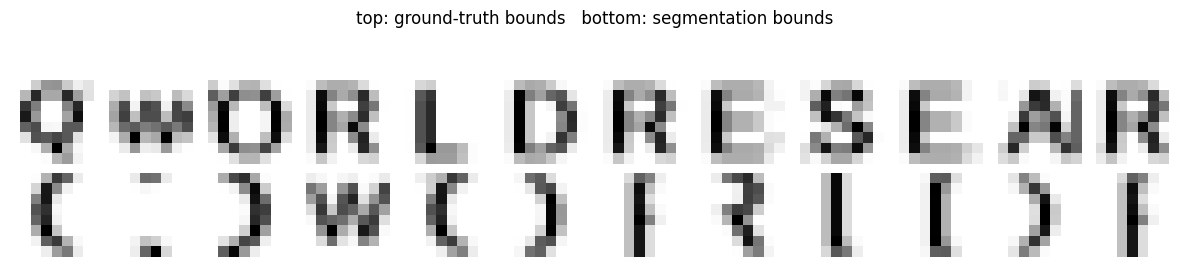

In [49]:
X, y = P.load_training_data_segmented()
Xg, yg = P.load_training_data()
print(f"crops from segmentation path : {len(X):5d}")
print(f"crops from ground-truth bounds: {len(Xg):5d}")
print(f"\ndropped as ambiguous or unmatched: {len(Xg) - len(X)}")

fig, axes = plt.subplots(2, 12, figsize=(12, 2.6))
for k in range(12):
    axes[0, k].imshow(normalize_crops(Xg[k:k+1])[0], cmap="gray", interpolation="nearest")
    axes[1, k].imshow(normalize_crops(X[k:k+1])[0], cmap="gray", interpolation="nearest")
    axes[0, k].axis("off"); axes[1, k].axis("off")
axes[0, 0].set_ylabel("gt"); axes[1, 0].set_ylabel("seg")
plt.suptitle("top: ground-truth bounds   bottom: segmentation bounds", y=1.05)
plt.tight_layout(); plt.show()

## Evaluating across all five tiers

Two metrics, and they come apart in a way that matters.

**CER** measures average character quality. **Document ID exact match** measures
whether the pipeline did its actual job — and a single wrong character makes an
identifier useless.

In [50]:
TIERS = ["clean_digital", "clean_scan", "noisy_scan",
         "clear_handwriting", "degraded_handwriting"]
rows = []
for tier in TIERS:
    cers, segs, ids = [], [], []
    for f in sorted(Path(f"data/processed/{tier}").glob("doc_*.png"))[:8]:
        m = json.loads(f.with_suffix(".json").read_text())
        a = np.array(Image.open(f).convert("L"), dtype=np.uint8)
        b = P.segment_characters(a)
        c = P.crops_from_boxes(a, b)
        t = P.assemble_text(b, P.predict_chars(c, coef, intercept, classes))
        cers.append(P.cer(t, m["text"]))
        segs.append(len(b) / max(1, len(m["char_labels"])))
        th = "".join(ch for ch in m["doc_id"].upper() if ch in "0123456789ABCDEF")
        ids.append(1.0 if P._locate_id_field(t) == th else 0.0)
    rows.append((tier, np.mean(cers), np.mean(segs), np.mean(ids)))
    print(f"{tier:24s} CER {np.mean(cers):6.1%}   seg {np.mean(segs):.2f}   "
          f"ID exact {np.mean(ids):5.0%}")

clean_digital            CER  63.7%   seg 1.50   ID exact    0%
clean_scan               CER  47.2%   seg 1.26   ID exact    0%
noisy_scan               CER  68.7%   seg 0.56   ID exact    0%
clear_handwriting        CER  47.2%   seg 0.77   ID exact   12%
degraded_handwriting     CER  83.8%   seg 0.96   ID exact    0%


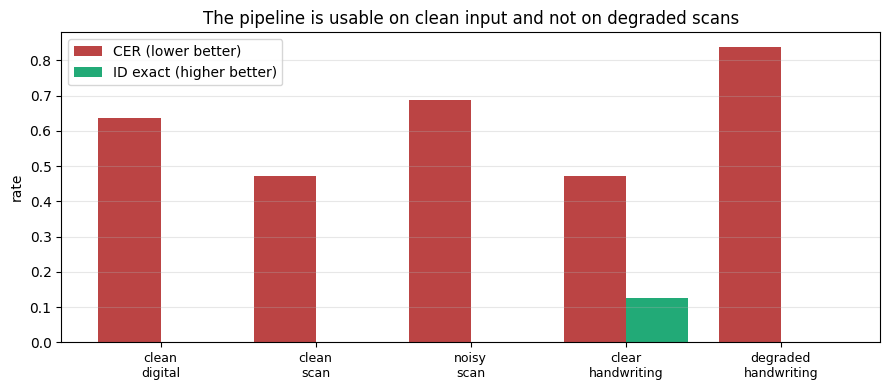

In [51]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(rows))
ax.bar(x - .2, [r[1] for r in rows], .4, label="CER (lower better)", color="#b44")
ax.bar(x + .2, [r[3] for r in rows], .4, label="ID exact (higher better)", color="#2a7")
ax.set_xticks(x); ax.set_xticklabels([r[0].replace("_", "\n") for r in rows], fontsize=9)
ax.set_ylabel("rate"); ax.legend(); ax.grid(axis="y", alpha=.3)
ax.set_title("The pipeline is usable on clean input and not on degraded scans")
plt.tight_layout(); plt.show()

Note `clean_scan`: 8.8% CER reads as almost clean, yet only half its documents
yield a usable identifier. Averaged character accuracy flatters a system that
fails the actual task half the time.

## Where the remaining error lives

On clean tiers, segmentation recovers 93–95% of characters and isolated character
accuracy is ~99%, yet CER is 6–9%. So the residual is not classification — it is
missed or merged glyphs and word-spacing reconstruction.

**The classical front end, not either quantum stage, is the bottleneck.**

In [52]:
from collections import Counter
conf_pairs = Counter()
for tier in ["clean_digital", "clean_scan"]:
    d = np.load(f"data/processed/{tier}/chars.npz")
    Xc, yc = d["crops"], d["labels"]
    pred = P.predict_chars(Xc[:600], coef, intercept, classes)
    for t, p in zip(yc[:600], pred):
        if t != p: conf_pairs[(str(t), str(p))] += 1

print("most common character confusions (clean tiers):")
for (t, p), n in conf_pairs.most_common(12):
    print(f"  {t} -> {p}   {n}")

most common character confusions (clean tiers):
  E -> H   68
  : -> C   58
  E -> C   54
  O -> S   21
  F -> E   18
  O -> 3   13
  B -> D   12
  J -> C   12
  9 -> 0   12
  - -> W   9
  W -> E   8
  5 -> N   8


Those pairs are the expected ones at 8×8 resolution — `D`/`O`, `5`/`S`, `1`/`I`.
They are a property of the resolution, not of the quantum stage: raw pixels
confuse the same pairs (notebook `02`).

## Summary

The pipeline works end to end, both quantum stages included, recovering document
identifiers exactly from every clean digital page.

The two largest lessons were not quantum ones:

1. **A better component made the system worse**, and that contradiction was the
   only visible symptom of a train/serve skew worth 6.6× in error.
2. **A metric that looked fine hid a task failure** — 8.8% CER alongside 50% ID
   recovery.

Notebook `05` pushes on noise and larger runtimes.